In [2]:
from lpspline import bs, LpRegressor, l, pwl, cs
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from lpspline.datasets import load_by_dataset
from lpspline.constraints import Monotonic, Concave, Convex, Anchor, Bound
from lpspline.viz import plot_diagnostic

In [16]:
X = pl.DataFrame({'x': np.linspace(0, 10, 1000)})
y = pl.Series(np.sin(X['x']*2) * X['x'] + np.random.normal(0, 1, 1000))


✨ Model Summary ✨
Problem Status: ❌ user_limit
------------------------------------------------------------------------------------------------------------------------
Spline Type          | Term         | Tag             | Constraints          | Penalties            | Params  
------------------------------------------------------------------------------------------------------------------------
🟢 BSpline           | x            | bspline         | Bound                | None                 | 22      
------------------------------------------------------------------------------------------------------------------------
📊 Total Parameters                                                                                 | 22



/home/clarkmaio/workspace/lpspline/.venv/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


(<Figure size 500x400 with 1 Axes>, array([<Axes: xlabel='x'>], dtype=object))

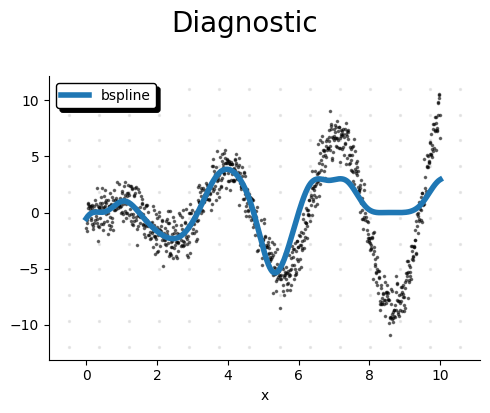

In [15]:
estimator = (
    +bs(term='x', knots=20)
        .add_constraint(Bound(lower=0, upper=3, n=1000, start=6, end=100))
)
estimator.fit(X, y)
plot_diagnostic(model=estimator, X=X, y=y)